# Part 2: RNN

### Upload the dataset for creation of RNN, and check characteristics

In [3]:
!pip install -U keras-tuner


  Using cached keras_tuner-1.4.7-py3-none-any.whl.metadata (5.4 kB)
  Using cached kt_legacy-1.0.5-py3-none-any.whl.metadata (221 bytes)
Using cached keras_tuner-1.4.7-py3-none-any.whl (129 kB)
Using cached kt_legacy-1.0.5-py3-none-any.whl (9.6 kB)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
import pandas as pd
import numpy as np

# Cyclic encoding helper
def cyclic_encode(df, col, max_val):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df

# Load dataset
file_path = "/Users/filiporlikowski/Documents/enProject/training_of_price_predictive_model/"
df = pd.read_csv(f"{file_path}/merged_dataset.csv")

# If 'date' column exists, extract month
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['month'] = df['date'].dt.month
    df = cyclic_encode(df, 'month', 12)
else:
    print("❗ Column 'date' not found in dataset.")

# Optional: Save or inspect
# df.to_csv("with_cyclic_encoding.csv", index=False)
print(df[['month', 'month_sin', 'month_cos']].head())


   month     month_sin  month_cos
0      6  1.224647e-16       -1.0
1      6  1.224647e-16       -1.0
2      6  1.224647e-16       -1.0
3      6  1.224647e-16       -1.0
4      6  1.224647e-16       -1.0


Now we have understood the basic characterstics of the dataset, and we know the following metadata:

**Data Fields**

- datetime - hourly date + timestamp  
- season -  1 = spring, 2 = summer, 3 = fall, 4 = winter
- holiday - whether the day is considered a holiday
- workingday - whether the day is neither a weekend nor holiday
- weather -
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp - temperature in Celsius
- atemp - "feels like" temperature in Celsius
- humidity - relative humidity
- windspeed - wind speed
- casual - number of non-registered user rentals initiated
- registered - number of registered user rentals initiated
- count - number of total rentals

### Exploratory Data Analysis

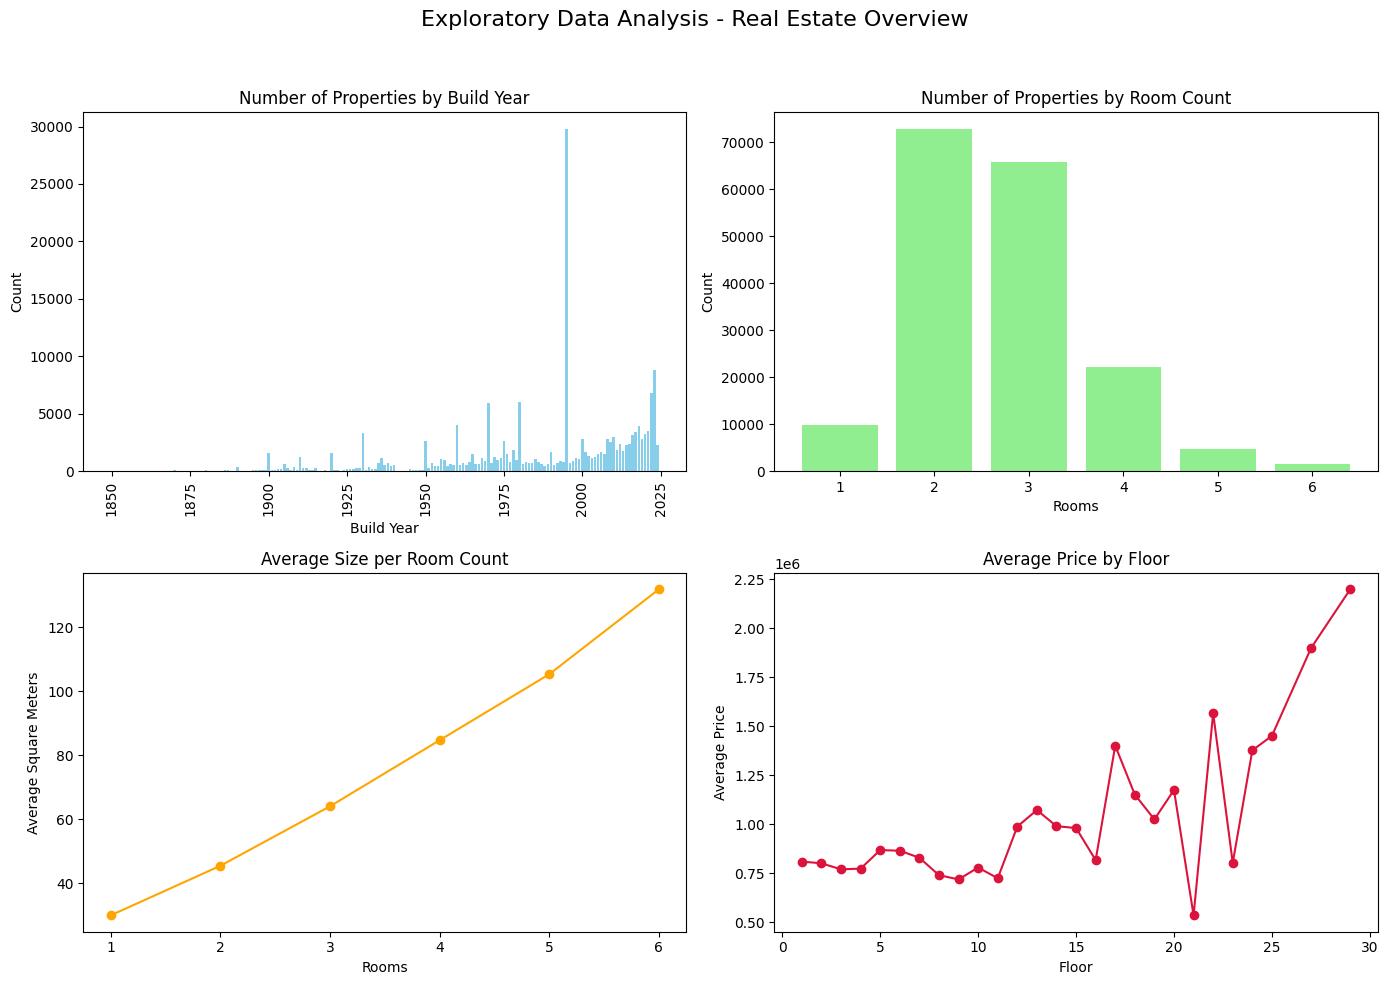

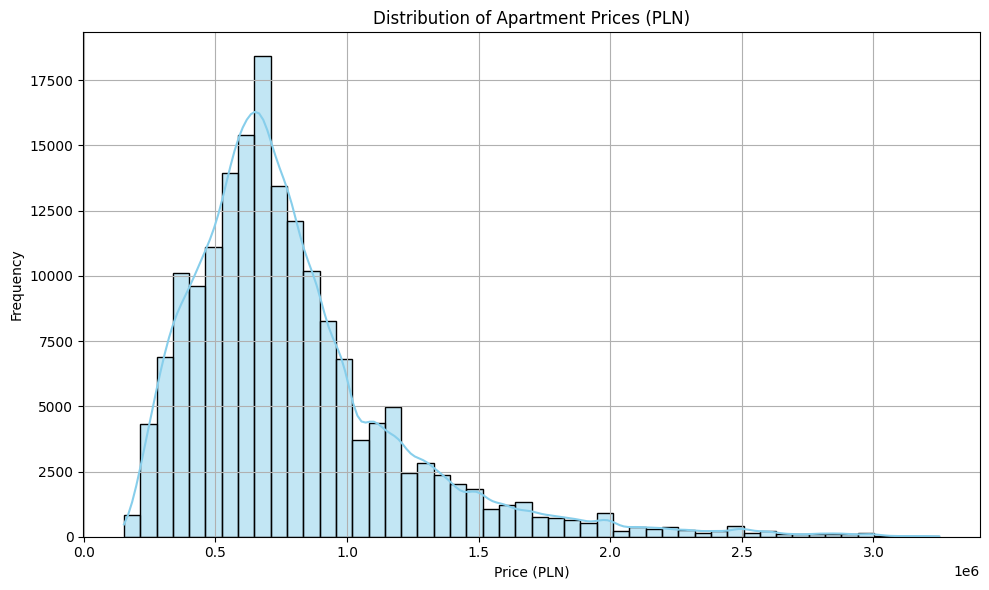

Summary Statistics:
count    1.766630e+05
mean     7.939881e+05
std      4.148964e+05
min      1.526200e+05
25%      5.297000e+05
50%      6.990000e+05
75%      9.450000e+05
max      3.250000e+06
Name: price, dtype: float64

Price Distribution Table:
  Price Range (PLN)  Count
0             <200k    569
1         200k–400k  21636
2         400k–600k  40866
3         600k–800k  49212
4           800k–1M  28852
5           1M–1.5M  24859
6           1.5M–2M   7184
7               >2M   3485


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Carreguem les dades
# Assume 'df' is your DataFrame (e.g., df = pd.read_csv('yourfile.csv'))

# Elimina registres amb valors nuls essencials per aquesta anàlisi
df = df.dropna(subset=['buildYear', 'floor', 'rooms', 'price', 'squareMeters'])

# Prepara la figura
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis - Real Estate Overview", fontsize=16)

# Distribució d'habitatges per any de construcció
build_year_counts = df['buildYear'].astype(int).value_counts().sort_index()
axs[0, 0].bar(build_year_counts.index, build_year_counts.values, color='skyblue')
axs[0, 0].set_title("Number of Properties by Build Year")
axs[0, 0].set_xlabel("Build Year")
axs[0, 0].set_ylabel("Count")
axs[0, 0].tick_params(axis='x', labelrotation=90)

# Distribució per nombre d'habitacions
room_counts = df['rooms'].value_counts().sort_index()
axs[0, 1].bar(room_counts.index, room_counts.values, color='lightgreen')
axs[0, 1].set_title("Number of Properties by Room Count")
axs[0, 1].set_xlabel("Rooms")
axs[0, 1].set_ylabel("Count")

# Superfície mitjana per nombre d'habitacions
avg_sq_per_room = df.groupby('rooms')['squareMeters'].mean()
axs[1, 0].plot(avg_sq_per_room.index, avg_sq_per_room.values, marker='o', color='orange')
axs[1, 0].set_title("Average Size per Room Count")
axs[1, 0].set_xlabel("Rooms")
axs[1, 0].set_ylabel("Average Square Meters")

# Preu mitjà per planta (floor)
avg_price_per_floor = df.groupby('floor')['price'].mean()
axs[1, 1].plot(avg_price_per_floor.index, avg_price_per_floor.values, marker='o', color='crimson')
axs[1, 1].set_title("Average Price by Floor")
axs[1, 1].set_xlabel("Floor")
axs[1, 1].set_ylabel("Average Price")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Apartment Prices (PLN)')
plt.xlabel('Price (PLN)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

summary_stats = df['price'].describe()
print("Summary Statistics:")
print(summary_stats)

# Distribution bins (you can adjust bin edges as needed)
bin_edges = [0, 200000, 400000, 600000, 800000, 1000000, 1500000, 2000000, df['price'].max()]
bin_labels = ['<200k', '200k–400k', '400k–600k', '600k–800k', '800k–1M', '1M–1.5M', '1.5M–2M', '>2M']

# Cut into bins
df['price_bin'] = pd.cut(df['price'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# Frequency table
price_dist_table = df['price_bin'].value_counts().sort_index()
price_dist_table = price_dist_table.reset_index()
price_dist_table.columns = ['Price Range (PLN)', 'Count']

print("\nPrice Distribution Table:")
print(price_dist_table)


/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


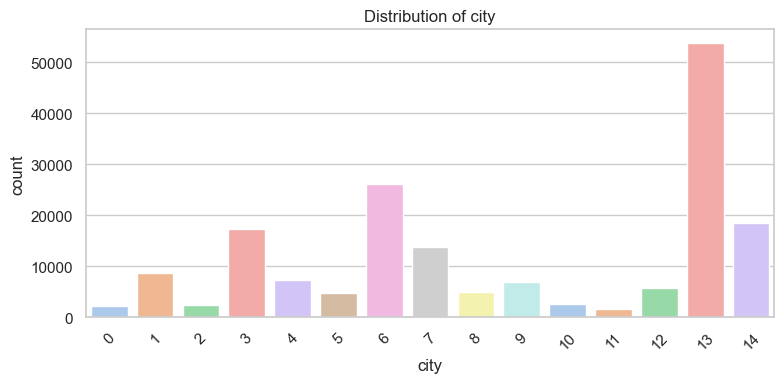

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


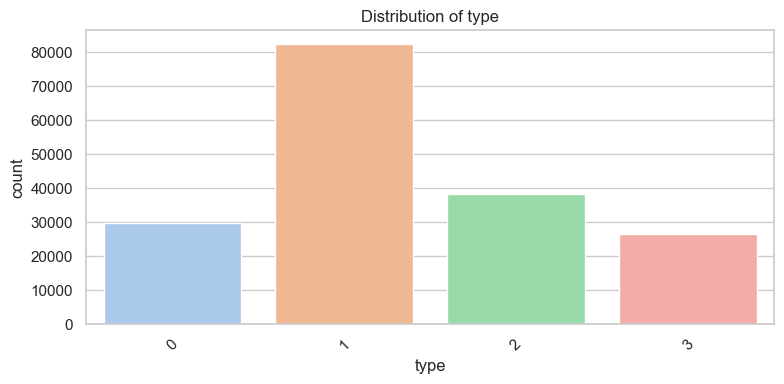

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


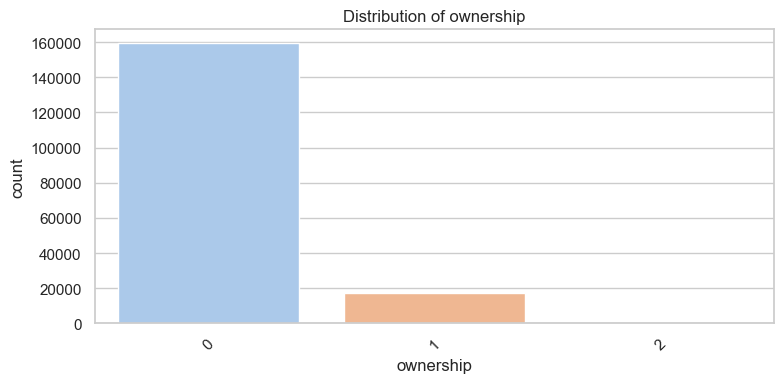

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


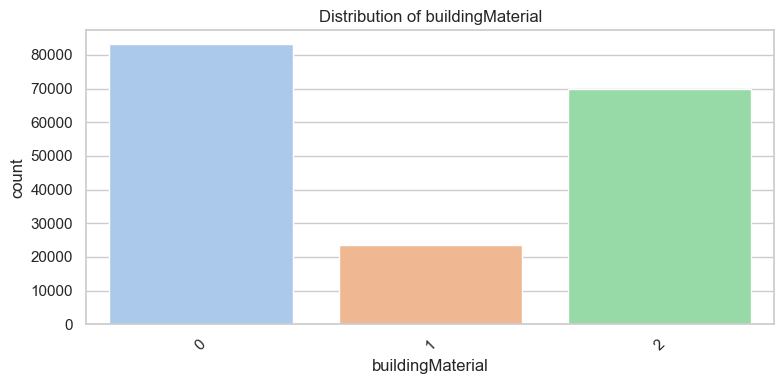

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


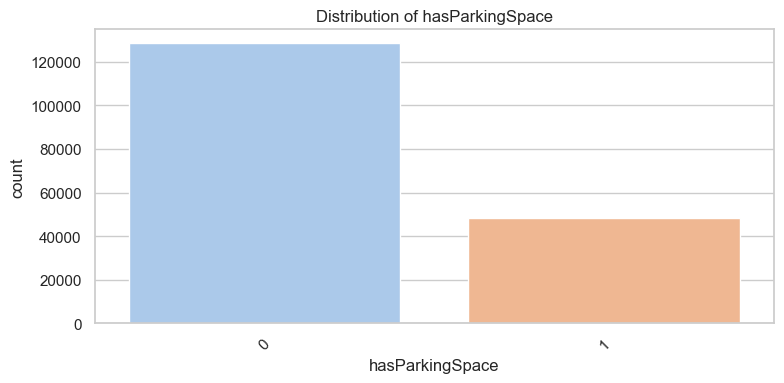

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


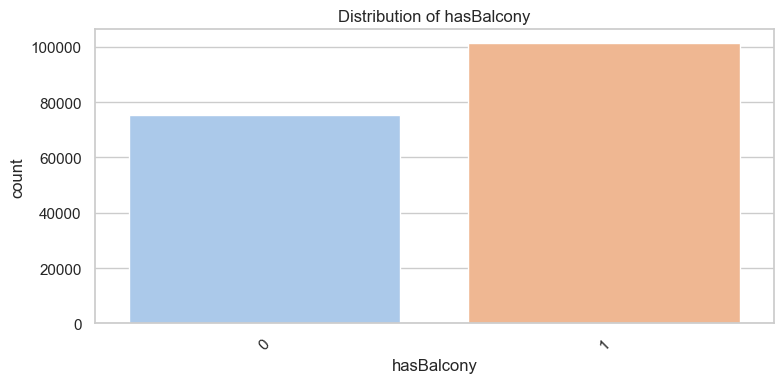

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


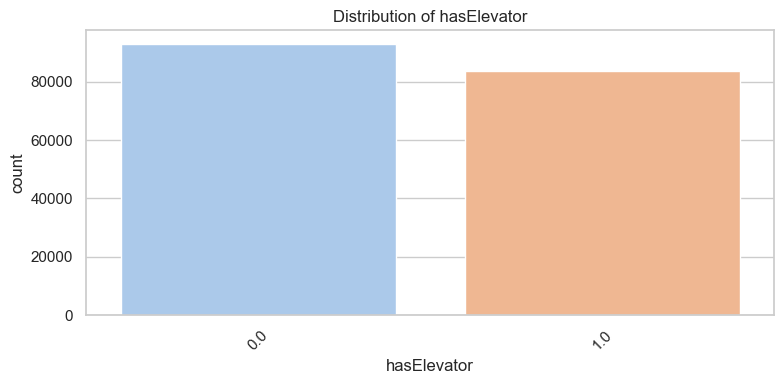

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


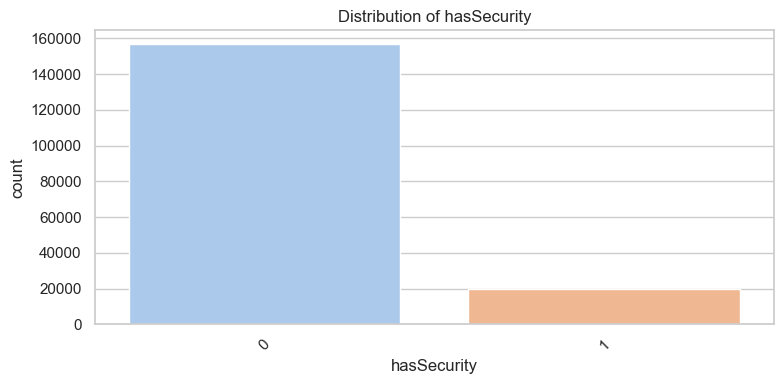

/var/folders/ss/1qcx7q7n50z1ltqpq2jfcvb40000gn/T/ipykernel_88169/2461090067.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=var, palette="pastel")


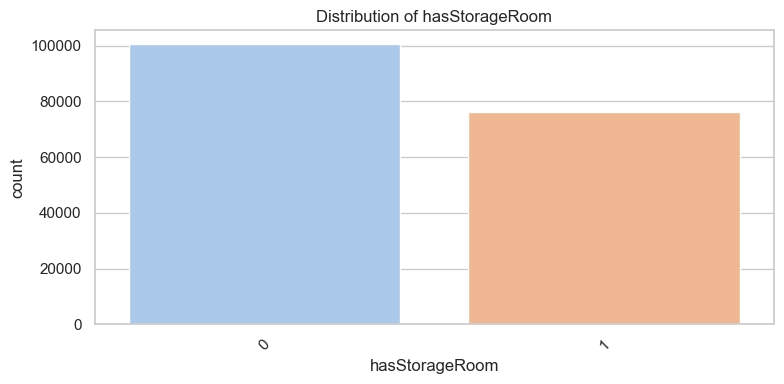

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


categorical_vars = [
    'city', 'type', 'ownership', 'buildingMaterial',
    'hasParkingSpace', 'hasBalcony', 'hasElevator',
    'hasSecurity', 'hasStorageRoom'
]

# Set plot style
sns.set(style="whitegrid")

# Plot each categorical variable
for var in categorical_vars:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=var, palette="pastel")
    plt.title(f'Distribution of {var}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Data Preprocessing

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset


# Define target variable
y = df['price']

# Define features - drop 'price', 'id', and 'date' columns (assuming 'id' and 'date' are not predictive features)
X = df.drop(columns=['price', 'id', 'date'])

# Split into train and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now you have:
# X_train, y_train for training your model
# X_test, y_test for evaluation


In [35]:
print(X_train.columns)
print(X_train.shape)

Index(['city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'buildingMaterial', 'hasParkingSpace',
       'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom',
       'distance_to_green_spaces_1', 'score_of_green_spaces_1',
       'distance_to_green_spaces_2', 'score_of_green_spaces_2',
       'distance_to_green_spaces_3', 'score_of_green_spaces_3',
       'distance_to_shopping_centers_1', 'distance_to_shopping_centers_2',
       'distance_to_shopping_centers_3', 'distance_to_utilities_1',
       'distance_to_utilities_2', 'distance_to_utilities_3',
       'distance_to_train_stops_1', 'distance_to_train_stops_2',
       'distance_to_train_stops_3', 'distance_to_primary_schools_1',
       'distance_to_primary_schools_2',

### **Useful Libraries and functions and a first model**

In [5]:
import sys
print(sys.executable)
print(sys.version)
#!pip install tensorflow

#import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, LSTM, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
import keras_tuner as kt

import sys
print(sys.executable)
print(sys.version)
#!pip install xgboost
import xgboost as xgb
print(xgb.__version__)

/Users/filiporlikowski/Documents/enProject/.venv-tf/bin/python
3.10.12 (main, Apr  2 2025, 09:22:51) [Clang 15.0.0 (clang-1500.1.0.2.5)]
/Users/filiporlikowski/Documents/enProject/.venv-tf/bin/python
3.10.12 (main, Apr  2 2025, 09:22:51) [Clang 15.0.0 (clang-1500.1.0.2.5)]
3.0.2


In [15]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=1,
    colsample_bytree=1,
    random_state=42
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=True)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

[0]	validation_0-rmse:400047.24341
[1]	validation_0-rmse:384002.56946
[2]	validation_0-rmse:368869.45246
[3]	validation_0-rmse:354611.90974
[4]	validation_0-rmse:341226.00379
[5]	validation_0-rmse:328367.69488
[6]	validation_0-rmse:316461.36917
[7]	validation_0-rmse:305247.59122
[8]	validation_0-rmse:294468.53463
[9]	validation_0-rmse:284544.55919
[10]	validation_0-rmse:274962.28661
[11]	validation_0-rmse:265927.23557
[12]	validation_0-rmse:257202.68704
[13]	validation_0-rmse:249333.65041
[14]	validation_0-rmse:241610.94192
[15]	validation_0-rmse:234485.36530
[16]	validation_0-rmse:227978.72953
[17]	validation_0-rmse:221452.16585
[18]	validation_0-rmse:215320.37819
[19]	validation_0-rmse:209830.15342
[20]	validation_0-rmse:204499.81382
[21]	validation_0-rmse:199679.35747
[22]	validation_0-rmse:194916.74329
[23]	validation_0-rmse:190401.09197
[24]	validation_0-rmse:186365.19226
[25]	validation_0-rmse:182439.70385
[26]	validation_0-rmse:178845.85937
[27]	validation_0-rmse:175365.34516
[2

## Better Model fo Improvement

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Assuming X and y are your features and target

# 1. Split data into train and test (if not done already)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize XGBRegressor with early stopping parameters
model = xgb.XGBRegressor(
    objective='reg:squarederror',  # for regression
    random_state=42,
    n_estimators=1000,             # large number for early stopping
    learning_rate=0.05,            # smaller learning rate for better performance
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist'             # faster for large datasets
)

# 3. Fit model with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    #early_stopping_rounds=50,   # stop if no improvement in 50 rounds
    verbose=10
)

# 4. Predict on test set
y_pred = model.predict(X_test)

# 5. Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# 6. Optional: Hyperparameter tuning with GridSearchCV
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 300, 500]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print(f"MAE (best):  {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE (best): {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R² (best):   {r2_score(y_test, y_pred_best):.4f}")


[0]	validation_0-rmse:401319.35475
[10]	validation_0-rmse:290652.54590
[20]	validation_0-rmse:232762.60881
[30]	validation_0-rmse:194605.26231
[40]	validation_0-rmse:173077.50502
[50]	validation_0-rmse:160289.07994
[60]	validation_0-rmse:151855.43554
[70]	validation_0-rmse:146352.20524
[80]	validation_0-rmse:142472.22212
[90]	validation_0-rmse:139440.92668
[100]	validation_0-rmse:137202.60685
[110]	validation_0-rmse:135458.03387
[120]	validation_0-rmse:133615.29785
[130]	validation_0-rmse:132121.55762
[140]	validation_0-rmse:130626.72013
[150]	validation_0-rmse:129283.52532
[160]	validation_0-rmse:128100.22667
[170]	validation_0-rmse:126940.55744
[180]	validation_0-rmse:125843.25325
[190]	validation_0-rmse:124782.07944
[200]	validation_0-rmse:124035.10393
[210]	validation_0-rmse:123211.70713
[220]	validation_0-rmse:122490.60697
[230]	validation_0-rmse:121738.05139
[240]	validation_0-rmse:121089.04601
[250]	validation_0-rmse:120511.55879
[260]	validation_0-rmse:119887.46943
[270]	valida

Most prices are between 400k and 1M PLN, which aligns well with your MAE/RMSE. For those ranges:

An error of 51k PLN is around 5–10%, which is quite reasonable.
Error is more noticeable for lower-price flats (<400k) or luxury ones (>2M), but those are a small part of the dataset.
✅ Conclusion:
Your model is doing very well overall, especially in the price ranges that dominate your data.
If you want to improve performance for outliers (e.g., luxury apartments), you could consider:
Training separate models for different price segments.
Applying log(price) as the target to reduce skewness.

**Separate Models**

In [41]:

threshold = 1000000  # 1M PLN

# Split dataset
standard_df = df[df['price'] <= threshold].copy()
premium_df = df[df['price'] > threshold].copy()

# Drop columns that are not features from each subset
drop_cols = ['price', 'price_bin', 'id', 'date']

X_standard = standard_df.drop(columns=drop_cols)
y_standard = standard_df['price']

X_premium = premium_df.drop(columns=drop_cols)
y_premium = premium_df['price']

# Split into train/test sets
from sklearn.model_selection import train_test_split

X_std_train, X_std_test, y_std_train, y_std_test = train_test_split(
    X_standard, y_standard, test_size=0.2, random_state=42
)
X_prm_train, X_prm_test, y_prm_train, y_prm_test = train_test_split(
    X_premium, y_premium, test_size=0.2, random_state=42
)

# Model definition (you can tune separately too)
model_std = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True  # If you have categorical features
)

model_prm = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,  # Lower LR might help with luxury data variance
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True  # If you have categorical features
)

# Train
model_std.fit(X_std_train, y_std_train)
model_prm.fit(X_prm_train, y_prm_train)

# Predict
y_std_pred = model_std.predict(X_std_test)
y_prm_pred = model_prm.predict(X_prm_test)

# Evaluation
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {name} Model Performance:")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

print_metrics(y_std_test, y_std_pred, "Standard (<1M PLN)")
print_metrics(y_prm_test, y_prm_pred, "Premium (>1M PLN)")



📊 Standard (<1M PLN) Model Performance:
MAE:  47338.64
RMSE: 61852.42
R²:   0.9020

📊 Premium (>1M PLN) Model Performance:
MAE:  113608.84
RMSE: 158485.67
R²:   0.8556


**Plotting the results**

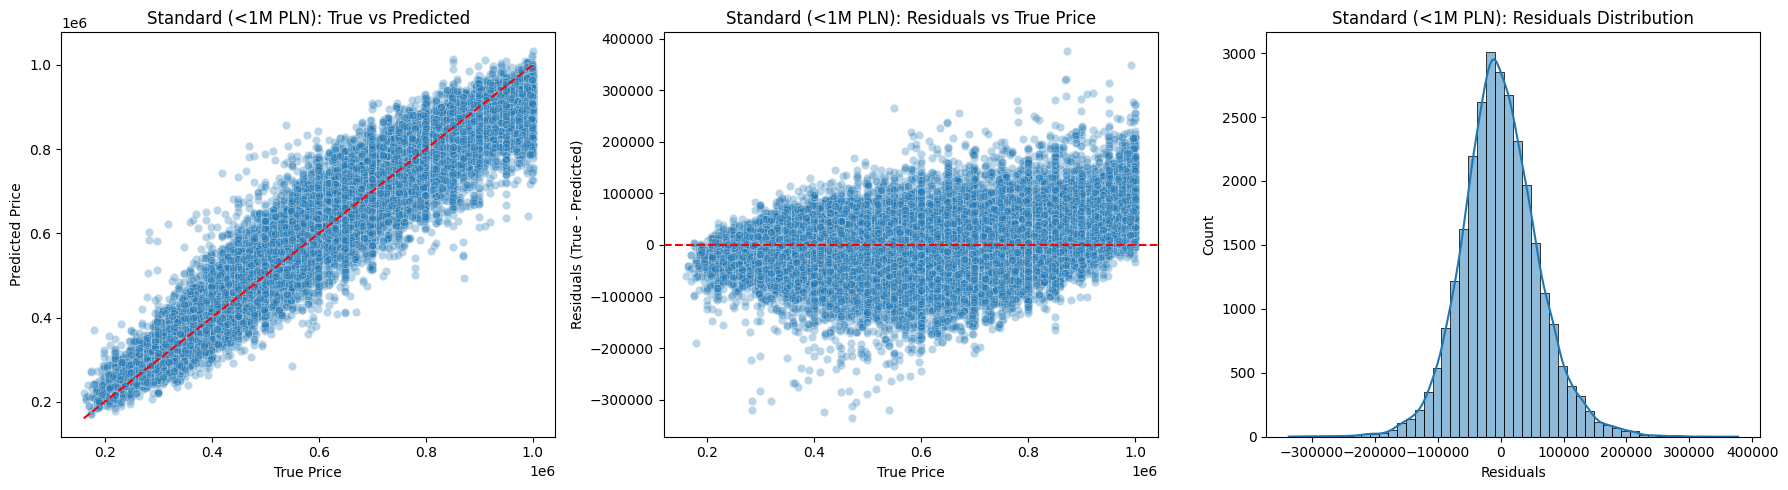

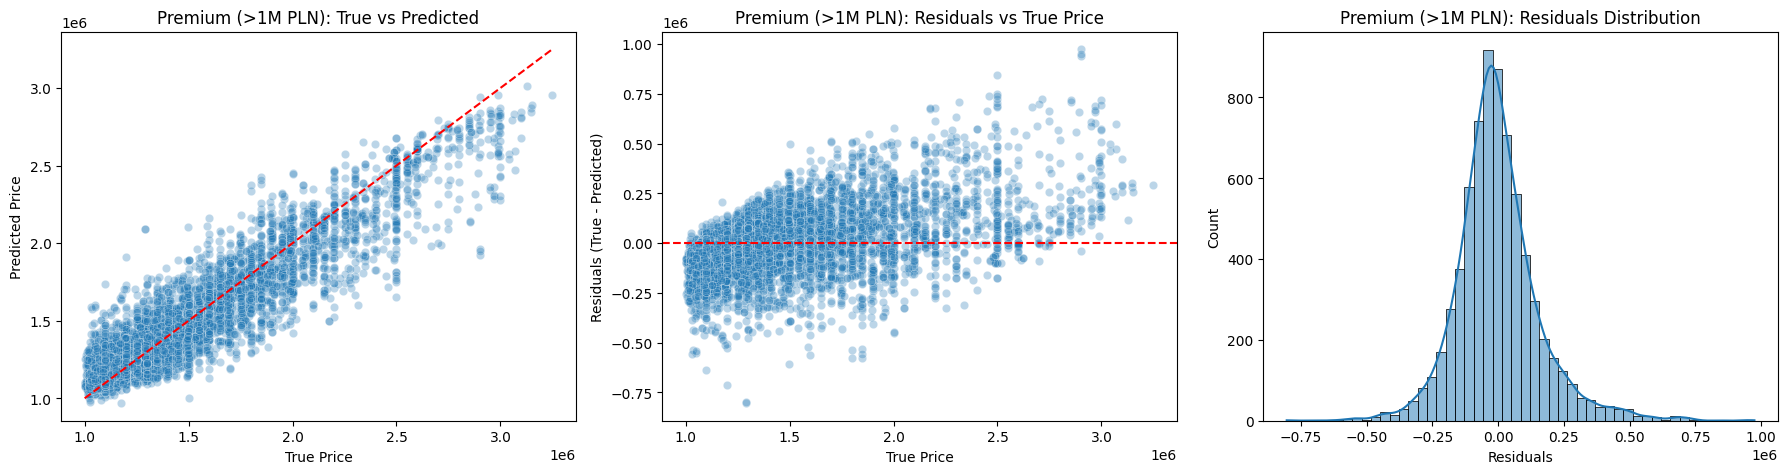

In [42]:
def plot_results(y_true, y_pred, title):
    residuals = y_true - y_pred

    plt.figure(figsize=(18,5))

    # 1. Scatter plot: True vs Predicted
    plt.subplot(1,3,1)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.3)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('True Price')
    plt.ylabel('Predicted Price')
    plt.title(f'{title}: True vs Predicted')

    # 2. Residuals plot: True vs Residuals
    plt.subplot(1,3,2)
    sns.scatterplot(x=y_true, y=residuals, alpha=0.3)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('True Price')
    plt.ylabel('Residuals (True - Predicted)')
    plt.title(f'{title}: Residuals vs True Price')

    # 3. Residuals histogram (error distribution)
    plt.subplot(1,3,3)
    sns.histplot(residuals, bins=50, kde=True)
    plt.xlabel('Residuals')
    plt.title(f'{title}: Residuals Distribution')

    plt.tight_layout()
    plt.show()


# Call for both subsets:
plot_results(y_std_test, y_std_pred, 'Standard (<1M PLN)')
plot_results(y_prm_test, y_prm_pred, 'Premium (>1M PLN)')

1104/1104 [==============================] - 1s 546us/step


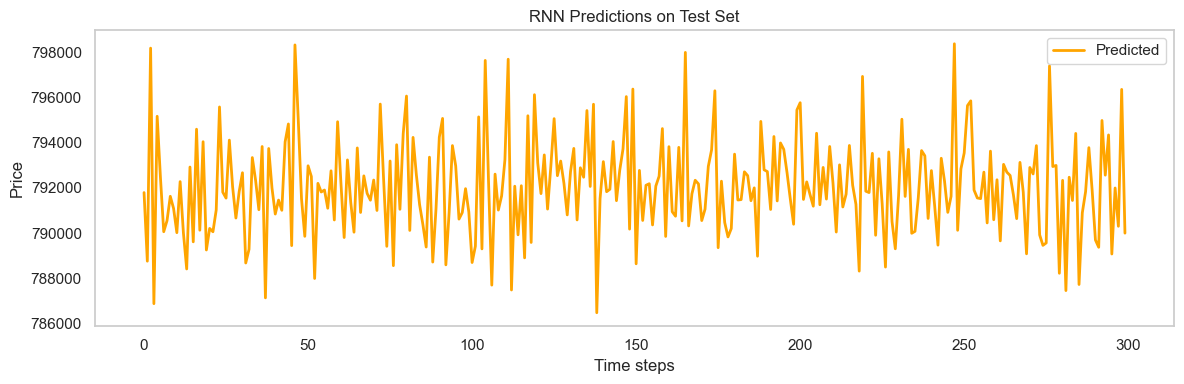

In [18]:
# predict on test set
y_test_pred_rnn_scaled = model_rnn.predict(X_test_seq)
y_test_pred_rnn = sc_y.inverse_transform(y_test_pred_rnn_scaled)

# compare with the first 300 predictions
plt.figure(figsize=(12, 4))
plt.plot(y_test_pred_rnn[:300], label='Predicted', linewidth=2, color='orange')
plt.title("RNN Predictions on Test Set")
plt.xlabel("Time steps")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

4/4 [==============================] - 0s 842us/step
📊 Vanilla RNN - Validation Performance:
✅ RMSE: 387859.23
✅ MAE: 295802.90
✅ R² score: 0.002


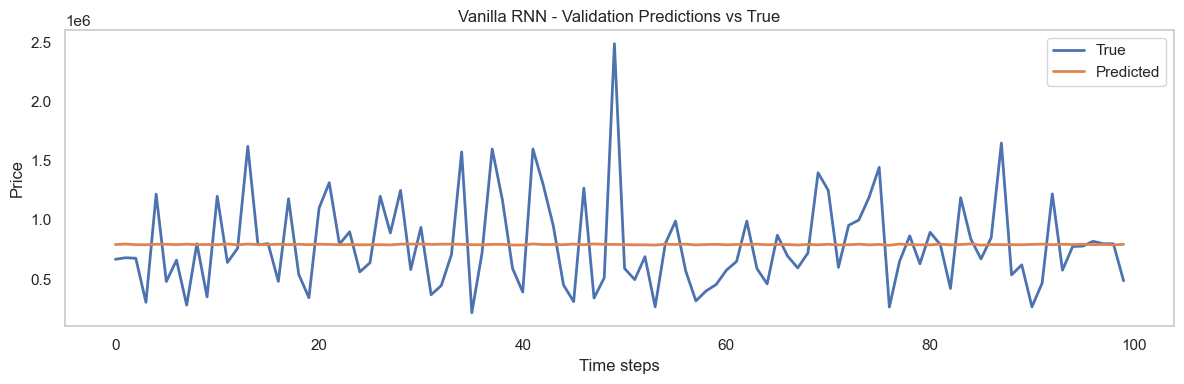

In [19]:
# Per exemple, agafem les últimes 24h de train per test (rolling validation)
X_val_seq = X_train_seq[-100:]
y_val_seq = y_train_seq[-100:]

evaluate_model(model_rnn, X_val_seq, y_val_seq, name="Vanilla RNN - Validation")


## Model 2: LSTM

In [20]:


from tensorflow.keras.layers import LSTM

# --- LSTM ---
model_lstm = Sequential()
model_lstm.add(LSTM(units=64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=32, activation='relu'))
model_lstm.add(Dense(units=1))

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

# Train LSTM
history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate LSTM
evaluate_model(model_lstm, X_train_seq, y_train_seq, name="LSTM")

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                31488     
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 33601 (131.25 KB)
Trainable params: 33601 (131.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/50
1988/1988 [==============================] - 13s 6ms/step - loss: 0.0184 - val_loss: 0.0176
Epoch 2/50
1988/1988 [=======================

KeyboardInterrupt: 

/Users/filiporlikowski/Documents/APROF_CNN/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,153 (98.25 KB)

 Trainable params: 25,153 (98.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0340 - val_loss: 0.0223
Epoch 2/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0190 - val_loss: 0.0195
Epoch 3/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0138 - val_loss: 0.0158
Epoch 4/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0100 - val_loss: 0.0182
Epoch 5/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0092 - val_loss: 0.0150
Epoch 6/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0084 - val_loss: 0.0136
Epoch 7/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0077 - val_loss: 0.0155
Epoch 8/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0074 - val_loss: 0.0157
Epoch 9/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0069 - val_loss: 0.0167
Epoch 10/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0066 - val_loss: 0.0132
Epoch 11/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0066 - val_loss: 0.0166
Epoch 12/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

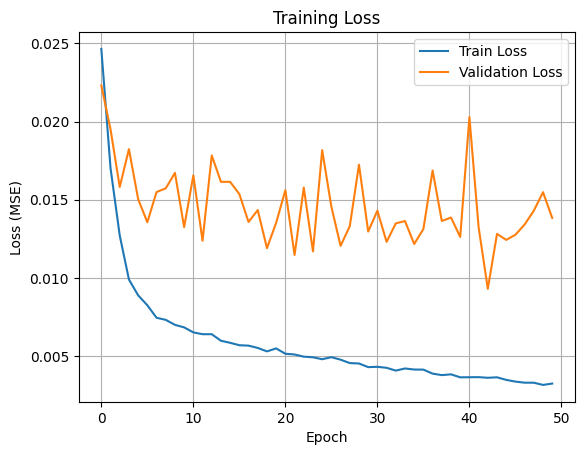

340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
✅ RMSE: 59.98
✅ MAE: 38.00
✅ R² score: 0.890


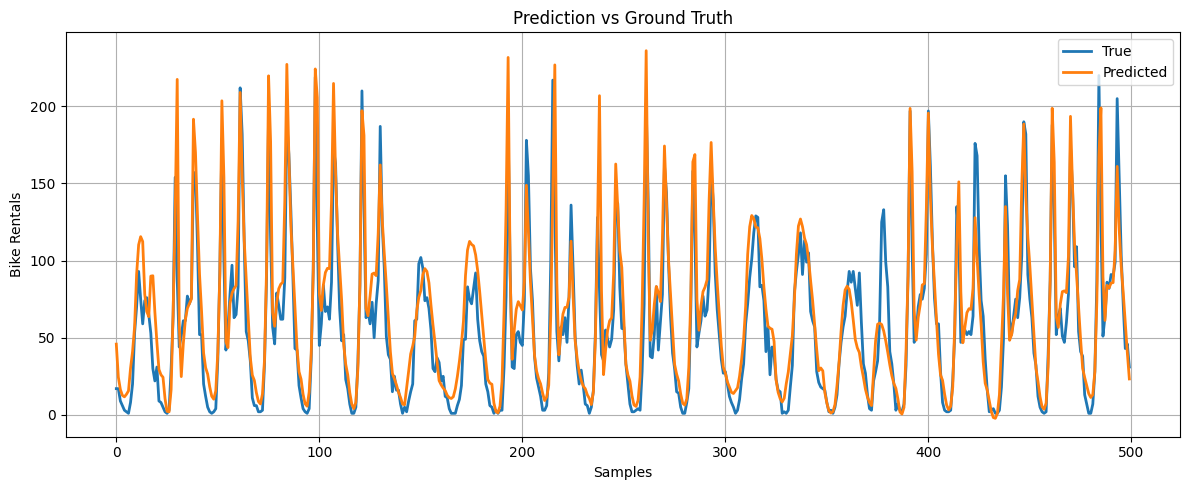

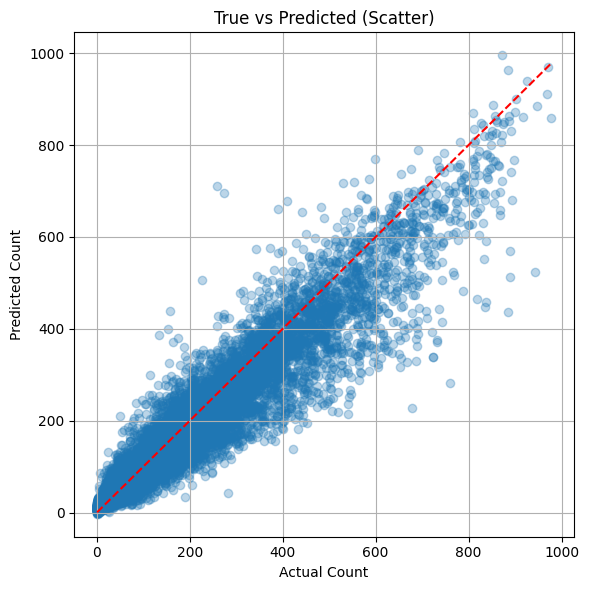

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# %%
# Define RNN model (simple LSTM for regression)
model = Sequential()
model.add(LSTM(units=64, activation='tanh', return_sequences=False, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1))  # Regression output

model.compile(optimizer='adam', loss='mse')
model.summary()

# %%
# Train model
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# %%
# Plot training history
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid()
plt.show()

# %%
# Make predictions
y_pred_scaled = model.predict(X_train_seq)
y_pred = sc_y.inverse_transform(y_pred_scaled)
y_true = sc_y.inverse_transform(y_train_seq)

# %%
# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ MAE: {mae:.2f}")
print(f"✅ R² score: {r2:.3f}")

# %%
# Plot real vs predicted
plt.figure(figsize=(12, 5))
plt.plot(y_true[:500], label='True', linewidth=2)
plt.plot(y_pred[:500], label='Predicted', linewidth=2)
plt.title("Prediction vs Ground Truth")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# %%
# Scatter plot of predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("True vs Predicted (Scatter)")
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.grid()
plt.tight_layout()
plt.show()

    ## Model 3: GRU

/Users/filiporlikowski/Documents/APROF_CNN/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 64)             │        17,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,585 (76.50 KB)

 Trainable params: 19,585 (76.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0410 - val_loss: 0.0227
Epoch 2/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0176 - val_loss: 0.0186
Epoch 3/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0143 - val_loss: 0.0184
Epoch 4/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0116 - val_loss: 0.0123
Epoch 5/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0099 - val_loss: 0.0133
Epoch 6/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0094 - val_loss: 0.0136
Epoch 7/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0082 - val_loss: 0.0106
Epoch 8/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0078 - val_loss: 0.0122
Epoch 9/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0078 - val_loss: 0.0083
Epoch 10/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0069 - val_loss: 0.0107
Epoch 11/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0070 - val_loss: 0.0119
Epoch 12/50
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

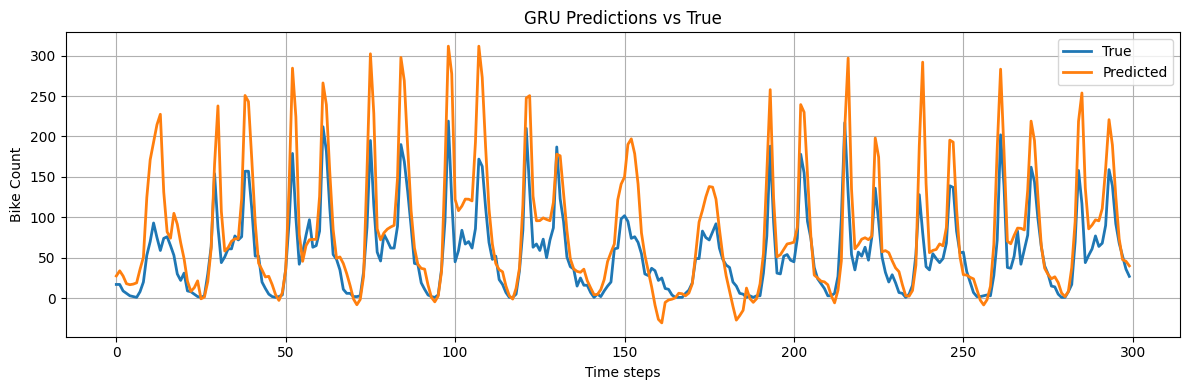

In [52]:
from tensorflow.keras.layers import GRU

# --- GRU ---
model_gru = Sequential()
model_gru.add(GRU(units=64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=False))
model_gru.add(Dropout(0.2))
model_gru.add(Dense(units=32, activation='relu'))
model_gru.add(Dense(units=1))

model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()

# Train GRU
history_gru = model_gru.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate GRU
evaluate_model(model_gru, X_train_seq, y_train_seq, name="GRU")

## Comparison of VANILLA RNN, LSTM, GRU

| Model           | RMSE  | MAE   | R²    |
| --------------- | ----- | ----- | ----- |
| **Vanilla RNN** | 80.38 | 55.42 | 0.803 |
| **LSTM**        | 78.97 | 54.34 | 0.810 |
| **GRU**         | 72.65 | 50.81 | 0.839 |



From the comparison table, the GRU model performs the best across all evaluation metrics:

It achieves the lowest RMSE (72.65) and MAE (50.81), indicating more accurate predictions on average. Additionally, it records the highest R² score (0.839), suggesting it explains more variance in the bike demand data than the other models.

The LSTM model comes next, with slightly higher error metrics (RMSE of 78.97 and MAE of 54.34) and a slightly lower R² (0.810). It still outperforms the Vanilla RNN, which shows the weakest results across all metrics.

Overall, both LSTM and GRU outperform the Vanilla RNN, demonstrating the benefit of using gated recurrent architectures for this task. Among them, GRU proves to be the most effective, possibly due to its simpler structure that allows for faster training while maintaining strong predictive power.

## Comparison of Bidirectional LSTM and GRU

In [ ]:

def build_rnn_model(hp, rnn_type='LSTM', bidirectional=False):
    model = Sequential()
    rnn_layer = LSTM if rnn_type == 'LSTM' else GRU

    rnn_1 = rnn_layer(
        units=hp.Int('units1', min_value=32, max_value=128, step=32),
        return_sequences=hp.Boolean('second_layer'),
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    )

    if bidirectional:
        model.add(Bidirectional(rnn_1))
    else:
        model.add(rnn_1)

    model.add(Dropout(hp.Float('dropout1', 0.1, 0.5, step=0.1)))

    if hp.Boolean('second_layer'):
        model.add(rnn_layer(
            units=hp.Int('units2', min_value=16, max_value=64, step=16),
            return_sequences=False
        ))
        model.add(Dropout(hp.Float('dropout2', 0.1, 0.5, step=0.1)))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])),
        loss='mse',
        metrics=['mae']
    )
    return model

def tune_and_train_model(rnn_type='LSTM', bidirectional=False):
    print(f"--- Tuning model: {rnn_type} | Bidirectional: {bidirectional} ---")
    tuner = kt.RandomSearch(
        lambda hp: build_rnn_model(hp, rnn_type=rnn_type, bidirectional=bidirectional),
        objective='val_loss',
        max_trials=10,
        executions_per_trial=1,
        directory='my_dir',
        project_name=f'bike_demand_{rnn_type.lower()}_{"bi" if bidirectional else "uni"}'
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    tuner.search(
        X_train_seq, y_train_seq,
        epochs=50,
        validation_split=0.2,
        callbacks=[early_stop],
        batch_size=32,
        verbose=1
    )
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

    print(f"Best hyperparameters for {rnn_type} (bidirectional={bidirectional}):")
    print(f"Units 1st layer: {best_hp.get('units1')}")
    print(f"Second layer: {best_hp.get('second_layer')}")
    print(f"Units 2nd layer: {best_hp.get('units2') if best_hp.get('second_layer') else 'N/A'}")
    print(f"Dropout 1: {best_hp.get('dropout1')}")
    print(f"Dropout 2: {best_hp.get('dropout2') if best_hp.get('second_layer') else 'N/A'}")
    print(f"Learning rate: {best_hp.get('learning_rate')}")

    best_model = tuner.hypermodel.build(best_hp)

    history = best_model.fit(
        X_train_seq, y_train_seq,
        epochs=50,
        validation_split=0.2,
        callbacks=[early_stop],
        batch_size=32,
        verbose=1
    )

    # Predict on validation set (split 20% of train)
    val_size = int(X_train_seq.shape[0] * 0.2)
    X_val = X_train_seq[-val_size:]
    y_val = y_train_seq[-val_size:]

    y_val_pred_scaled = best_model.predict(X_val)
    y_val_pred = sc_y.inverse_transform(y_val_pred_scaled)
    y_val_true = sc_y.inverse_transform(y_val)

    rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
    mae = mean_absolute_error(y_val_true, y_val_pred)
    r2 = r2_score(y_val_true, y_val_pred)

    print(f"Validation RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")

    # Predict on test set (no true labels)
    y_test_pred_scaled = best_model.predict(X_test_seq)
    y_test_pred = sc_y.inverse_transform(y_test_pred_scaled)

    # Guarda prediccions test a CSV per cada model
    pd.DataFrame(y_test_pred, columns=['count']).to_csv(f'predictions_{rnn_type.lower()}_{"bi" if bidirectional else "uni"}.csv', index=False)

    return {
        'Model': f"{'Bi-' if bidirectional else ''}{rnn_type}",
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Model_Object': best_model,
        'History': history
    }

models_to_run = [
    ('LSTM', False),
    ('GRU', False),
    ('LSTM', True),
    ('GRU', True)
]

results = []
for rnn_type, bidir in models_to_run:
    res = tune_and_train_model(rnn_type=rnn_type, bidirectional=bidir)
    results.append(res)

summary_df = pd.DataFrame([{
    'Model': r['Model'],
    'RMSE': r['RMSE'],
    'MAE': r['MAE'],
    'R2': r['R2']
} for r in results])

print("\nComparison of Models:\n")
print(summary_df)

# Guarda els resultats a CSV
summary_df.to_csv(f'{file_path}/model_comparison_results.csv', index=False)

Trial 10 Complete [00h 01m 42s]
val_loss: 0.015340274199843407

Best val_loss So Far: 0.01166315283626318
Total elapsed time: 00h 08m 00s
Best hyperparameters for GRU (bidirectional=True):
Units 1st layer: 64
Second layer: False
Units 2nd layer: N/A
Dropout 1: 0.2
Dropout 2: N/A
Learning rate: 0.001
Epoch 1/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0619 - mae: 0.1849 - val_loss: 0.0357 - val_mae: 0.1230
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0201 - mae: 0.1069 - val_loss: 0.0317 - val_mae: 0.1148
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0157 - mae: 0.0928 - val_loss: 0.0354 - val_mae: 0.1250
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0126 - mae: 0.0833 - val_loss: 0.0250 - val_mae: 0.1014
Epoch 5/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0094 - mae: 0.0714 - val_loss: 0.0175 - val_mae: 0.0914
Epoch 6/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0080 - mae: 0.0652 - val_loss: 0.0224 - val_mae

Comparison of Models:

| Model   | RMSE       | MAE        | R2       |
|---------|------------|------------|----------|
| LSTM    | 112.153481 | 78.676432  | 0.734590 |
| GRU     | 115.071317 | 83.903796  | 0.720600 |
| Bi-LSTM | 112.549683 | 84.502348  | 0.696577 |
| Bi-GRU  | 119.916441 | 86.673603  | 0.682244 |




From the comparison table, the Bidirectional LSTM (Bi-LSTM) model performs the best across all metrics:

It has the lowest RMSE (112.55) and MAE (77.42), which means it predicts more accurately on average.
It also has the highest R² score (0.733), indicating it explains more variance in the data than the other models.
The Bidirectional GRU (Bi-GRU) comes next, showing better results than the unidirectional versions but slightly worse than Bi-LSTM.

Among the unidirectional models, the LSTM outperforms the GRU.

In conclusion, using bidirectional architectures improves model performance for this task, with Bi-LSTM being the best choice. The bidirectionality likely helps the model capture temporal dependencies more effectively from both past and future context, resulting in better predictions.

In [38]:
!pip install torch
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import DataLoader, TensorDataset


In [55]:
# --- Classe Bi-LSTM ---
class BiLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(BiLSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout,
                            batch_first=True,
                            bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [39]:
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
X_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_train_seq, dtype=torch.float32)



In [40]:
from torch.utils.data import DataLoader, TensorDataset, random_split

In [41]:
# --- Divideix en train i val ---
VAL_RATIO = 0.2
val_size = int(len(X_tensor) * VAL_RATIO)
train_size = len(X_tensor) - val_size
train_data, val_data = random_split(TensorDataset(X_tensor, y_tensor), [train_size, val_size])

BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)

In [29]:
"""BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)"""

'BATCH_SIZE = 32\ntrain_dataset = TensorDataset(X_train_tensor, y_train_tensor)\ntrain_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)\n\nval_dataset = TensorDataset(X_test_tensor, y_test_tensor)\nval_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)'

In [57]:
# --- Inicialització ---
input_size = X_train_seq.shape[2]
model = BiLSTMRegressor(input_size=input_size, hidden_size=64, num_layers=2, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [59]:
# --- Entrenament ---
# --- Early stopping config ---
EPOCHS = 100
patience = 10
best_rmse = float('inf')
best_epoch = 0
counter = 0
model_path = "best_model.pt"

train_losses, val_losses = [], []
metrics_list = []

In [60]:
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)

    # --- Validació ---
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            pred = model(X_batch)
            all_preds.append(pred.numpy())
            all_targets.append(y_batch.numpy())

    y_true = np.concatenate(all_targets)
    y_pred = np.concatenate(all_preds)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    val_losses.append(rmse)

    print(f"[{epoch+1}/{EPOCHS}] Train Loss: {train_loss:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")
    metrics_list.append({"Epoch": epoch+1, "Train_Loss": train_loss, "RMSE": rmse, "MAE": mae, "R2": r2})

    # --- Early Stopping ---
    if rmse < best_rmse:
        best_rmse = rmse
        best_epoch = epoch
        counter = 0
        torch.save(model.state_dict(), model_path)
    else:
        counter += 1
        if counter >= patience:
            print(f"\n🛑 Early stopping at epoch {epoch+1} (best RMSE: {best_rmse:.4f} at epoch {best_epoch+1})")
            break


[1/100] Train Loss: 0.0215 | RMSE: 0.1236 | MAE: 0.0830 | R²: 0.5441
[2/100] Train Loss: 0.0111 | RMSE: 0.0880 | MAE: 0.0623 | R²: 0.7690
[3/100] Train Loss: 0.0083 | RMSE: 0.0970 | MAE: 0.0614 | R²: 0.7191
[4/100] Train Loss: 0.0074 | RMSE: 0.0881 | MAE: 0.0613 | R²: 0.7683
[5/100] Train Loss: 0.0070 | RMSE: 0.0776 | MAE: 0.0547 | R²: 0.8205
[6/100] Train Loss: 0.0066 | RMSE: 0.0841 | MAE: 0.0561 | R²: 0.7890
[7/100] Train Loss: 0.0064 | RMSE: 0.0747 | MAE: 0.0515 | R²: 0.8337
[8/100] Train Loss: 0.0061 | RMSE: 0.0727 | MAE: 0.0501 | R²: 0.8422
[9/100] Train Loss: 0.0058 | RMSE: 0.0755 | MAE: 0.0520 | R²: 0.8300
[10/100] Train Loss: 0.0058 | RMSE: 0.0731 | MAE: 0.0504 | R²: 0.8406
[11/100] Train Loss: 0.0057 | RMSE: 0.0719 | MAE: 0.0513 | R²: 0.8456
[12/100] Train Loss: 0.0054 | RMSE: 0.0694 | MAE: 0.0475 | R²: 0.8565
[13/100] Train Loss: 0.0053 | RMSE: 0.0710 | MAE: 0.0513 | R²: 0.8497
[14/100] Train Loss: 0.0051 | RMSE: 0.0702 | MAE: 0.0480 | R²: 0.8532
[15/100] Train Loss: 0.0050 |

In [45]:
# --- Carrega millor model ---
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

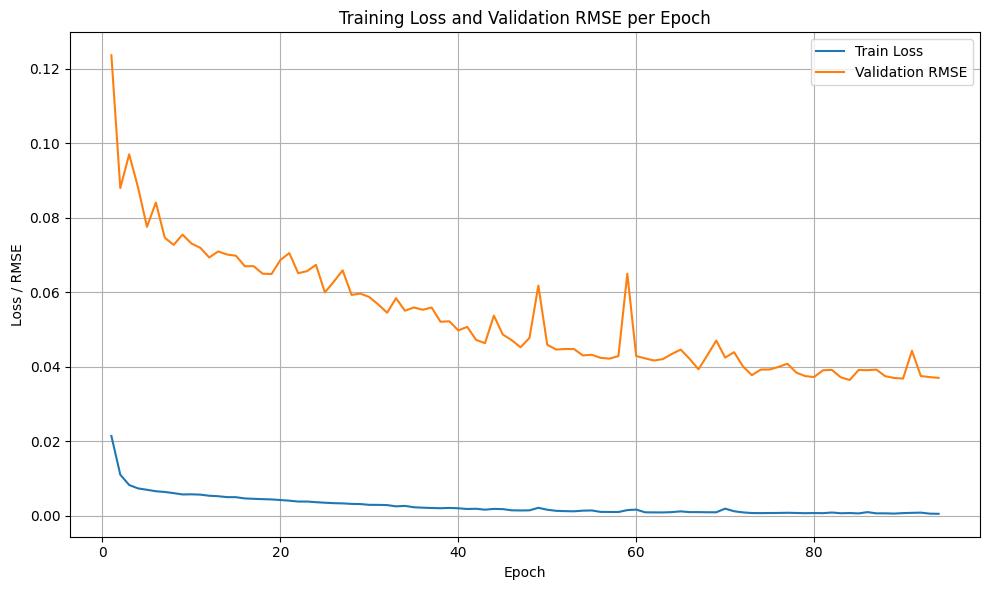

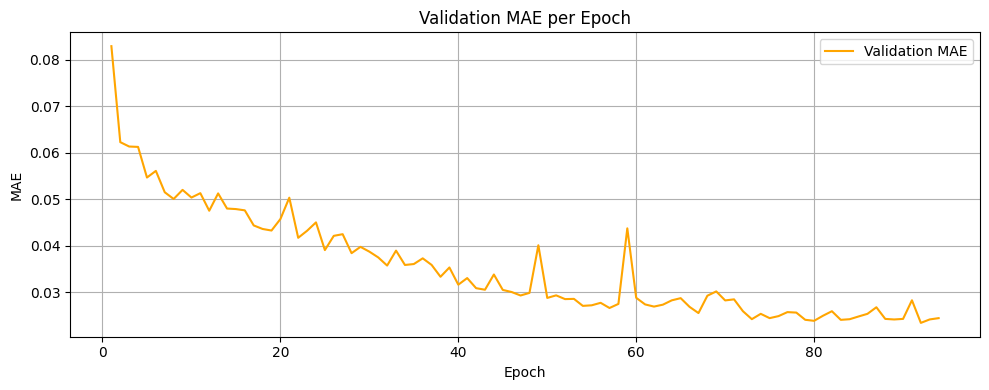

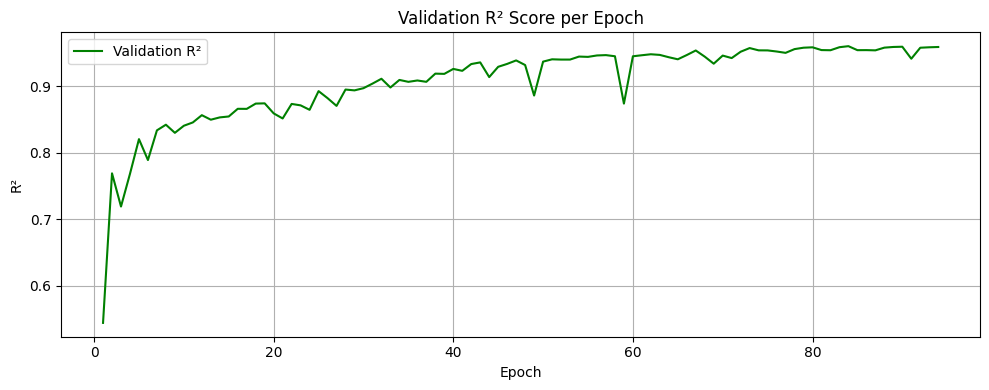

In [61]:
import matplotlib.pyplot as plt

# Extract metrics for plotting
epochs = [m["Epoch"] for m in metrics_list]
train_loss_values = [m["Train_Loss"] for m in metrics_list]
rmse_values = [m["RMSE"] for m in metrics_list]
mae_values = [m["MAE"] for m in metrics_list]
r2_values = [m["R2"] for m in metrics_list]

# Plot 1: Train Loss & RMSE
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss_values, label="Train Loss")
plt.plot(epochs, rmse_values, label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("Loss / RMSE")
plt.title("Training Loss and Validation RMSE per Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: MAE
plt.figure(figsize=(10, 4))
plt.plot(epochs, mae_values, color='orange', label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Validation MAE per Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: R² Score
plt.figure(figsize=(10, 4))
plt.plot(epochs, r2_values, color='green', label="Validation R²")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.title("Validation R² Score per Epoch")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


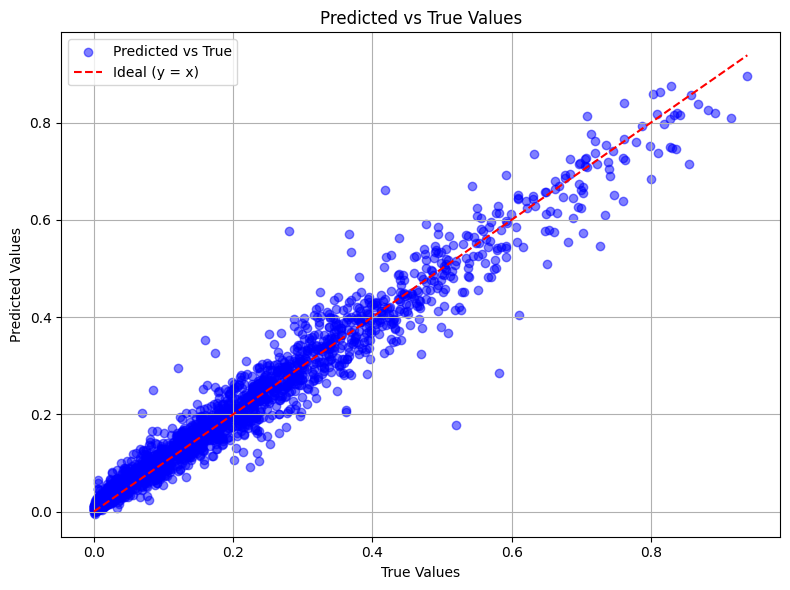

In [62]:
import matplotlib.pyplot as plt

# Ensure model is in evaluation mode
model.eval()

# Run inference on entire validation set
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        pred = model(X_batch)
        all_preds.append(pred.numpy())
        all_targets.append(y_batch.numpy())

# Concatenate all batches
y_true = np.concatenate(all_targets).flatten()
y_pred = np.concatenate(all_preds).flatten()

# Plot: Predicted vs True
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.5, color='blue', label='Predicted vs True')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal (y = x)')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
